In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [10]:
resp_sofa = [
    'sofa_resp_day1',
    'sofa_resp_day2',
    'sofa_resp_day3'
]

def preprocess_design_matrix(design_matrix):

    design_matrix = design_matrix[design_matrix['sofa_resp_baseline'] == 0]


    # design_matrix['sofa_resp_diff2'] = design_matrix['sofa_resp_day2'] - design_matrix['sofa_resp_baseline']
    # design_matrix['sofa_resp_diff3'] = design_matrix['sofa_resp_day3'] - design_matrix['sofa_resp_baseline']
    # design_matrix['sofa_resp_diff1'] = design_matrix['sofa_resp_day1'] - design_matrix['sofa_resp_baseline']

    # design_matrix['max_resp_diff'] = np.max(
    #     design_matrix[
    #         [
    #             'sofa_resp_day1',
    #             'sofa_resp_day2',
    #             'sofa_resp_day3'
    #         ]
    #     ],
    #     axis=1
    # )

    design_matrix = design_matrix[
        (design_matrix['Resp Rate'] < 0.5) |
        (design_matrix['Resp Rate'] > 0.8)
    ].copy()

    design_matrix['group'] = np.where(
        design_matrix['Resp Rate'] > 0.5, 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [11]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [12]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [13]:
design_matrix_otrain = pd.read_csv(
    "../3_feature_selection_organ_dysfunction/organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [14]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy())

<Axes: xlabel='Resp Rate', ylabel='Count'>

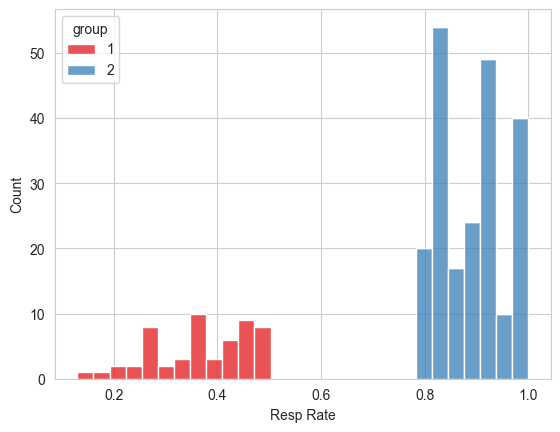

In [15]:
sns.histplot(
    design_matrix_train,
    x="Resp Rate",
    hue="group",
    palette="Set1",
    multiple="stack"
)

In [16]:
design_matrix_train['group'].value_counts()

group
2    214
1     55
Name: count, dtype: int64

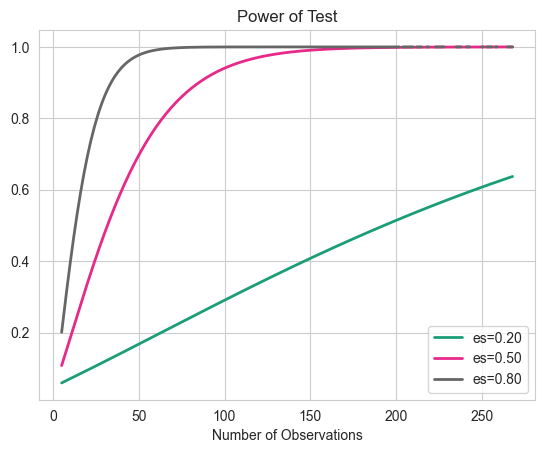

In [17]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [18]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

KeyError: "['SA_BOX_15-464_S4-G9_1_6763', 'SA_BOX_13-332_S1-H3_1_6519', 'SA_BOX_10-2413_S2-A7_1_6251', 'SA_BOX_12-2003_S5-H6_1_6445', 'SA_BOX_14-783_S2-B5_1_6627', 'SA_BOX_7-2541_S4-H2_1_5922', 'SA_BOX_11-2426_S4-G6_1_6346', 'SA_BOX_11-878_S4-C5_1_6334', 'SA_BOX_1-2586_S1-C3_1_6807', 'SA_BOX_5-334_S1-B1_1_5712', 'SA_BOX_1-273_S1-H2_1_6804', 'SA_BOX_8-1577_S5-F10_1_6083', 'SA_BOX_9-2604_S1-D7_1_6156', 'SA_BOX_8-1088_S5-D12_1_6097', 'SA_BOX_11-2428_S4-H3_1_6323', 'SA_BOX_4-242_S5-F9_1_5683', 'SA_BOX_7-2522_S4-G1_1_5913', 'SA_BOX_2-1559_S2-A8_1_6944', 'SA_BOX_13-91_S1-F7_1_6550', 'SA_BOX_7-1968_S4-F3_1_5928', 'SA_BOX_7-2629_S4-G9_1_5978', 'SA_BOX_11-1979_S4-D1_1_6303', 'SA_BOX_15-1938_S4-B9_1_6758', 'SA_BOX_1-1996_S1-H7_1_6845', 'SA_BOX_15-866_S4-H7_1_6748', 'SA_BOX_11-1663_S4-A10_1_6373', 'SA_BOX_13-499_S1-D3_1_6515', 'SA_BOX_1-274_S1-B1_1_6790', 'SA_BOX_14-2483_S2-H11_1_6682', 'SA_BOX_15-769_S4-D1_1_6695', 'SA_BOX_6-879_S2-F5_1_5846', 'SA_BOX_11-1726_S4-B10_1_6374', 'SA_BOX_12-303_S5-A4

In [19]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

NameError: name 'quant_matrix_train' is not defined

In [12]:
quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [13]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

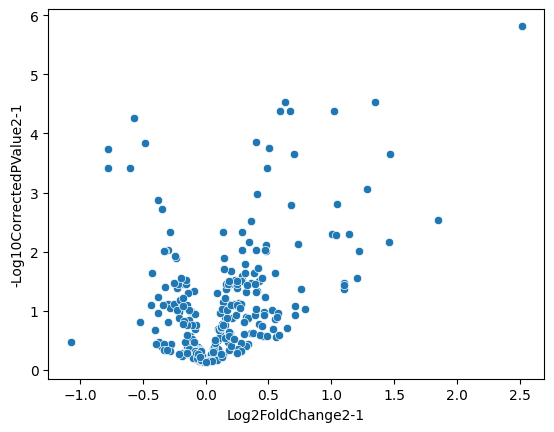

In [14]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [15]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [16]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [17]:
protein_columns = training_data.columns.to_list()

In [18]:
len(protein_columns)

287

In [19]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [21]:
from cleanlab.filter import find_label_issues
from sklearn.model_selection import cross_val_predict

pred_probs = cross_val_predict(protein_clf, X, y.values.ravel(), cv=3, method="predict_proba")

label_issues = find_label_issues(
    labels=y.values.ravel(),
    pred_probs=pred_probs,
    return_indices_ranked_by='self_confidence',  # Ranks by likelihood of being mislabeled
)

/srv/data1/home/aaron/envs/miniconda3/envs/revisionenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# label_issues

In [23]:
mask = np.ones(len(y.values.ravel()), dtype=bool)

mask[label_issues] = False

In [24]:
# mask.shape

In [25]:
X = X.iloc[mask, :].copy()
y = y.iloc[mask, :].copy()

In [26]:
y['label'].value_counts()

label
1    69
0    33
Name: count, dtype: int64

In [27]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y.values.ravel()),
    y=y.values.ravel()
)

class_weight = dict(zip(np.unique(y.values.ravel()), class_weight))

class_weight

{0: 1.5454545454545454, 1: 0.7391304347826086}

In [28]:
sample_weight = compute_sample_weight(
    class_weight=class_weight,
    y=y.values.ravel()
)

In [29]:
from mrmr import mrmr_classif
selected_proteins = mrmr_classif(X=X[protein_columns], y=y.values.ravel(), K=50)

100%|██████████| 50/50 [00:15<00:00,  3.14it/s]


In [30]:
selected_proteins

['PSPB_HUMAN',
 'NCAM1_HUMAN',
 'PCSK9_HUMAN',
 'IBP2_HUMAN',
 'COIA1_HUMAN',
 'ALS_HUMAN',
 'TSP1_HUMAN',
 'VWF_HUMAN',
 'CYTC_HUMAN',
 'FBLN5_HUMAN',
 'IBP3_HUMAN',
 'FBLN3_HUMAN',
 'TIMP1_HUMAN',
 'RS27A_HUMAN',
 'CNDP1_HUMAN',
 'RNAS1_HUMAN',
 'FETUA_HUMAN',
 'B2MG_HUMAN',
 'PCOC1_HUMAN',
 'LYSC_HUMAN',
 'PON1_HUMAN',
 'TENA_HUMAN',
 'IBP7_HUMAN',
 'ENOA_HUMAN',
 'FETUB_HUMAN',
 'NRP1_HUMAN',
 'HSP7C_HUMAN',
 'AACT_HUMAN',
 'CO7_HUMAN',
 'THBG_HUMAN',
 'SODC_HUMAN',
 'CALR_HUMAN',
 'MRC1_HUMAN',
 'APOL1_HUMAN',
 'CMGA_HUMAN',
 'CFAB_HUMAN',
 'TETN_HUMAN',
 'CFAD_HUMAN',
 'ITIH3_HUMAN',
 'A1AT_HUMAN',
 'BIP_HUMAN',
 'CATB_HUMAN',
 'FIBA_HUMAN',
 'C163A_HUMAN',
 'PTPRG_HUMAN',
 'APOC4_HUMAN',
 'VCAM1_HUMAN',
 'APOM_HUMAN',
 'PLTP_HUMAN',
 'VSIG4_HUMAN']

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, HistGradientBoostingClassifier


protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[selected_proteins], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.9420289855072465,
 0.9285375494071145,
 0.9117647058823529,
 0.8952569169960475)

In [33]:
from dpks.interpretation import BootstrapInterpreter

protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_proteins,
    downsample_background=True,
    shuffle_iterations=100
)

In [34]:
protein_interpreter.fit(X[selected_proteins].values, y.values.ravel(), protein_clf)

In [35]:
protein_importances = protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [36]:
protein_importances.head(20)

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
0,PSPB_HUMAN,1.000000,1.0,0.927450,2.0,0.541558,11.0,1.000000,1.0,0.533167,...,0.513666,10.0,0.791943,6.0,0.849041,0.932947,0.181712,3.38,2.0,3.933231
13,RS27A_HUMAN,0.247491,24.0,0.544404,14.0,0.882722,4.0,0.498582,5.0,1.000000,...,0.830010,5.0,0.501571,16.0,0.544790,0.500077,0.288217,13.62,9.0,12.946494
6,TSP1_HUMAN,0.222132,27.0,1.000000,1.0,1.000000,1.0,0.447948,7.0,0.503280,...,0.748239,6.0,0.649443,8.0,0.538858,0.547709,0.261312,12.55,8.0,11.823940
14,CNDP1_HUMAN,0.388074,12.0,0.748335,9.0,0.473616,13.0,0.540914,3.0,0.455413,...,0.367940,19.0,0.577315,13.0,0.537146,0.543043,0.242016,11.59,10.0,9.491192
29,THBG_HUMAN,0.272314,20.0,0.847622,3.0,0.925602,3.0,0.516987,4.0,0.379895,...,1.000000,1.0,0.872864,2.0,0.505028,0.456654,0.305340,14.88,9.5,13.460214
36,TETN_HUMAN,0.726246,3.0,0.794882,6.0,0.639350,9.0,0.354459,10.0,0.503689,...,0.605585,9.0,0.825901,3.0,0.493057,0.481781,0.218831,12.59,10.0,8.792898
20,PON1_HUMAN,0.621455,5.0,0.271554,33.0,0.956347,2.0,0.062571,42.0,0.243736,...,0.882016,3.0,0.540264,15.0,0.490732,0.454213,0.275092,15.29,12.5,12.817519
4,COIA1_HUMAN,0.449550,10.0,0.815720,5.0,0.380457,18.0,0.280438,13.0,0.376284,...,0.683450,7.0,0.364435,30.0,0.464038,0.458954,0.178706,13.42,11.0,8.235400
1,NCAM1_HUMAN,0.679641,4.0,0.009756,49.0,0.443154,16.0,0.219951,21.0,0.290270,...,0.229616,29.0,0.805989,5.0,0.461899,0.412724,0.252700,15.62,12.0,11.760042
3,IBP2_HUMAN,0.282326,18.0,0.407363,23.0,0.750245,6.0,0.490621,6.0,0.532454,...,0.318944,21.0,0.388269,26.0,0.458070,0.411614,0.188580,14.37,13.0,8.440708


In [37]:
selected_proteins = protein_importances.head(10)['feature'].to_list()

In [38]:
from dpks.interpretation import Classifier


protein_clf = Classifier(protein_clf)

In [39]:
selected_features = selected_proteins[:10]

In [40]:
for feature in selected_features:

    print(feature)

PSPB_HUMAN
RS27A_HUMAN
TSP1_HUMAN
CNDP1_HUMAN
THBG_HUMAN
TETN_HUMAN
PON1_HUMAN
COIA1_HUMAN
NCAM1_HUMAN
IBP2_HUMAN


In [41]:
protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [42]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[selected_features], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.9710144927536232,
 0.9571256038647343,
 0.9509803921568628,
 0.9400527009222661)

In [43]:
cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.9565217391304347,
 0.9317765567765569,
 0.9215686274509803,
 0.9025032938076416)

In [44]:
from dpks.interpretation import BootstrapInterpreter

final_protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_features,
    downsample_background=True,
    shuffle_iterations=100
    
)

In [45]:
final_protein_interpreter.fit(X[selected_features].values, y.values.ravel(), protein_clf)

In [46]:
final_protein_importances = final_protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [47]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
0,PSPB_HUMAN,1.000000,1.0,1.000000,1.0,0.710787,5.0,1.000000,1.0,0.973070,...,0.129009,9.0,0.689964,6.0,0.836586,0.941824,0.228864,2.72,2.0,2.335843
9,IBP2_HUMAN,0.494725,6.0,0.477553,6.0,0.870696,3.0,0.888423,2.0,0.738811,...,1.000000,1.0,1.000000,1.0,0.705412,0.715621,0.224543,3.67,3.0,1.969746
7,COIA1_HUMAN,0.887084,2.0,0.674325,2.0,0.607088,7.0,0.706298,3.0,0.609526,...,0.852756,2.0,0.732678,5.0,0.670040,0.680959,0.229061,4.05,4.0,2.152635
1,RS27A_HUMAN,0.623906,4.0,0.428444,8.0,0.609203,6.0,0.508667,5.0,1.000000,...,0.793147,3.0,0.925967,3.0,0.618677,0.584759,0.256749,4.82,5.0,2.555960
2,TSP1_HUMAN,0.248625,8.0,0.603713,3.0,1.000000,1.0,0.694806,4.0,0.481424,...,0.785329,4.0,0.571968,8.0,0.597664,0.599079,0.241866,4.89,5.0,2.424184
6,PON1_HUMAN,0.516073,5.0,0.011534,9.0,0.433204,8.0,0.016778,10.0,0.228773,...,0.746114,6.0,0.981739,2.0,0.474768,0.450207,0.279591,6.04,6.0,2.685238
4,THBG_HUMAN,0.202640,9.0,0.452603,7.0,0.873194,2.0,0.195312,8.0,0.434962,...,0.774564,5.0,0.751494,4.0,0.415308,0.374513,0.256039,6.83,7.0,2.502746
3,CNDP1_HUMAN,0.172936,10.0,0.479158,5.0,0.249837,9.0,0.428319,7.0,0.580681,...,0.294851,8.0,0.451748,9.0,0.407603,0.372340,0.218030,6.73,7.0,2.326201
5,TETN_HUMAN,0.743241,3.0,0.507521,4.0,0.752459,4.0,0.506099,6.0,0.563983,...,0.321933,7.0,0.573147,7.0,0.378956,0.347826,0.239543,7.13,8.0,2.650157
8,NCAM1_HUMAN,0.384509,7.0,0.000941,10.0,0.094552,10.0,0.128101,9.0,0.194175,...,0.064444,10.0,0.413032,10.0,0.276411,0.252049,0.176623,8.12,9.0,1.913693


In [48]:
final_protein_importances.to_csv(
    "feature_importances/resp_protein_importances.tsv",
    sep="\t",
    index=False
)

# Model Testing

In [49]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [50]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [51]:
quant_matrix_test_df = quant_matrix_test.to_df()
#quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [52]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [53]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [54]:
X_test = testing_data.copy()

X_test[protein_scaler.feature_names_in_] = protein_scaler.transform(X_test[protein_scaler.feature_names_in_])

X_test = X_test.copy()

In [55]:
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

random_forest = RandomForestClassifier(random_state=42)

svc = SVC(random_state=42)
knn = KNeighborsClassifier()
naive_bayes = GaussianNB()
mlp = MLPClassifier(random_state=42)


lr_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)



# lr_clf = GradientBoostingClassifier(
#     #estimator=random_forest,
#     random_state=42
# )

xgb_clf = XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    learning_rate=0.01,
    n_estimators=1000,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)




In [56]:
lr_clf.fit(X[selected_features], y.values.ravel()) #sample_weight=sample_weight)
xgb_clf.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
decision_tree.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight) 
random_forest.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
svc.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
knn.fit(X[selected_features], y.values.ravel()) 
naive_bayes.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight) 
mlp.fit(X[selected_features], y.values.ravel())

MLPClassifier(random_state=42)

In [57]:
from sklearn.metrics import f1_score

lr_predictions = lr_clf.predict(X_test[selected_features])
lr_ba = f1_score(y_test.values.ravel(), lr_predictions)

xgb_predictions = xgb_clf.predict(X_test[selected_features])
xgb_ba = f1_score(y_test.values.ravel(), xgb_predictions)

decision_tree_predictions = decision_tree.predict(X_test[selected_features])
decision_tree_ba = f1_score(y_test.values.ravel(), decision_tree_predictions)

rf_predictions = random_forest.predict(X_test[selected_features])
rf_ba = f1_score(y_test.values.ravel(), rf_predictions)

svc_predictions = svc.predict(X_test[selected_features])
svc_ba = f1_score(y_test.values.ravel(), svc_predictions)

knn_predictions = knn.predict(X_test[selected_features])
knn_ba = f1_score(y_test.values.ravel(), knn_predictions)

nb_predictions = naive_bayes.predict(X_test[selected_features])
nb_ba = f1_score(y_test.values.ravel(), nb_predictions)

mlp_predictions = mlp.predict(X_test[selected_features])
mlp_ba = f1_score(y_test.values.ravel(), mlp_predictions)

In [58]:
lr_ba, xgb_ba, decision_tree_ba, rf_ba, svc_ba, knn_ba, nb_ba, mlp_ba

(0.8333333333333334,
 0.8301886792452831,
 0.7643312101910829,
 0.8862275449101796,
 0.8104575163398693,
 0.8402366863905325,
 0.8,
 0.8553459119496856)

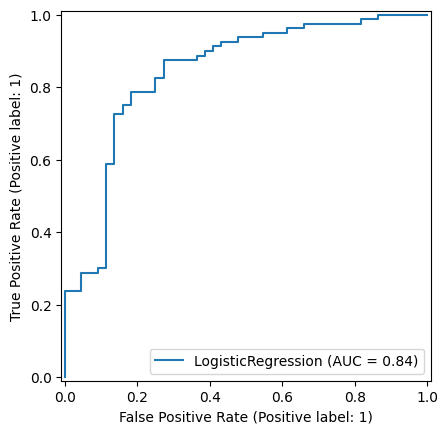

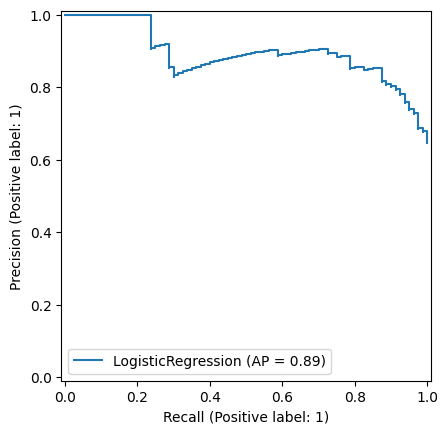

In [59]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)


PrecisionRecallDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)





In [60]:
from sklearn.metrics import roc_curve

y_probs = lr_clf.predict_proba(X_test[selected_features])[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve( y_test.values.ravel(), y_probs)

# Create a DataFrame to store the metrics
roc_df = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Threshold': thresholds
})


In [61]:
roc_df.to_csv(
    "roc/respiratory.tsv",
    sep="\t"
)

# Probability Prediction

In [62]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

design_matrix_test['sample'] = design_matrix_test['injection']
design_matrix_test['group'] = 1

quant_matrix_predict = QuantMatrix(
    quantification_file=ms_data_test,
    design_matrix_file=design_matrix_test,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)#.impute(method="uniform_percentile", percentile=0.01)

predict_data, y_test_alll = quant_matrix_predict.to_ml(feature_column="ProteinLabel")

In [63]:
predict_data = predict_data[protein_columns].copy()

In [64]:
predict_data[protein_columns] = protein_scaler.transform(predict_data[protein_columns])

In [65]:
predict_data['resp_probability'] = lr_clf.predict_proba(predict_data[selected_features])[:, 1]

In [66]:
design_matrix_test = design_matrix_test.set_index("injection").join(
    predict_data['resp_probability']
).reset_index()

In [67]:
predict_data[['resp_probability']].to_csv(
    "predictions_test/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

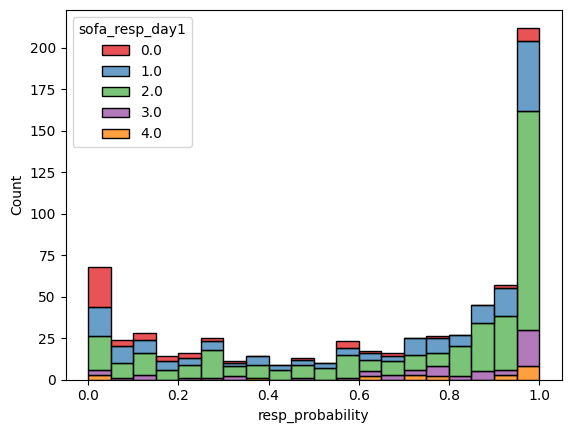

In [68]:
sns.histplot(
    data=design_matrix_test,
    x="resp_probability",
    hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [69]:
ms_data_val = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)

design_matrix_val = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

design_matrix_val['sample'] = design_matrix_val['injection']
design_matrix_val['group'] = 1

quant_matrix_val = QuantMatrix(
    quantification_file=ms_data_val,
    design_matrix_file=design_matrix_val,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

val_data, y_val = quant_matrix_val.to_ml(feature_column="ProteinLabel")

In [70]:
val_data = val_data[protein_columns].copy()

In [71]:
val_data[protein_columns] = protein_scaler.transform(val_data[protein_columns])

In [72]:
val_data['resp_probability'] = lr_clf.predict_proba(val_data[selected_features])[:, 1]

In [73]:
design_matrix_val = design_matrix_val.set_index("injection").join(
    val_data['resp_probability']
).reset_index()

In [74]:
val_data[['resp_probability']].to_csv(
    "predictions_val/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

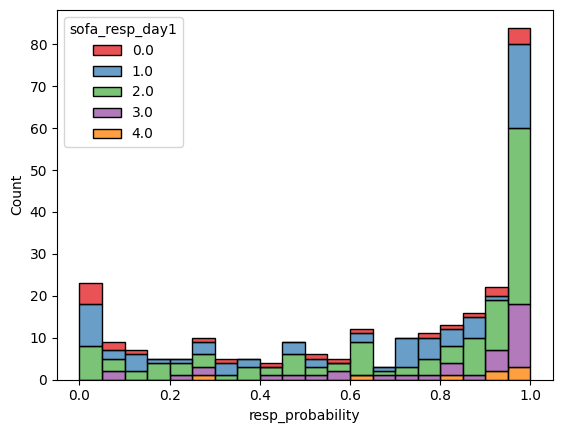

In [75]:
sns.histplot(
    data=design_matrix_val,
    x="resp_probability",
    hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [76]:
ms_data_hero = pd.read_csv(
    "../0_data/proteins_hero_filtered.tsv"
    , sep="\t"
)

design_matrix_hero = pd.read_csv(
    "../0_data/design_matrix_hero.tsv",
    sep='\t'
)

design_matrix_hero['sample'] = design_matrix_hero['injection']
design_matrix_hero['group'] = 1

quant_matrix_hero = QuantMatrix(
    quantification_file=ms_data_hero,
    design_matrix_file=design_matrix_hero,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

hero_data, y_hero = quant_matrix_hero.to_ml(feature_column="ProteinLabel")

In [77]:
hero_data = hero_data[protein_columns].copy()

In [78]:
hero_data[protein_columns] = protein_scaler.transform(hero_data[protein_columns])

In [79]:
hero_data['resp_probability'] = lr_clf.predict_proba(hero_data[selected_features])[:, 1]

In [80]:
design_matrix_hero = design_matrix_hero.set_index("injection").join(
    hero_data['resp_probability']
).reset_index()

In [81]:
hero_data[['resp_probability']].to_csv(
    "predictions_external/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

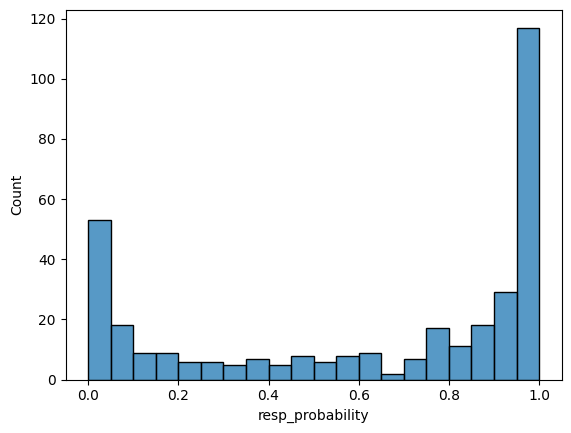

In [82]:
sns.histplot(
    data=hero_data,
    x="resp_probability",
    #hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [83]:
from joblib import dump


with open("models/resp_protein_model.pkl", "wb") as f:

    dump(lr_clf, f)

with open("models/resp_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
